# Context
Some samples also have min values outliers. I need to define the detection criterium. 
Also, I want to see how often single local 0 or 100 values happen and if a simple linear interpolation could fix the spectrum. 

I already analyzed elsewhere that max values are 99.9999 and min are 0.0

# Step 1: analyzing single runs where I identified min outliers


Some examples of samples are 7, 17, 35, or 44.

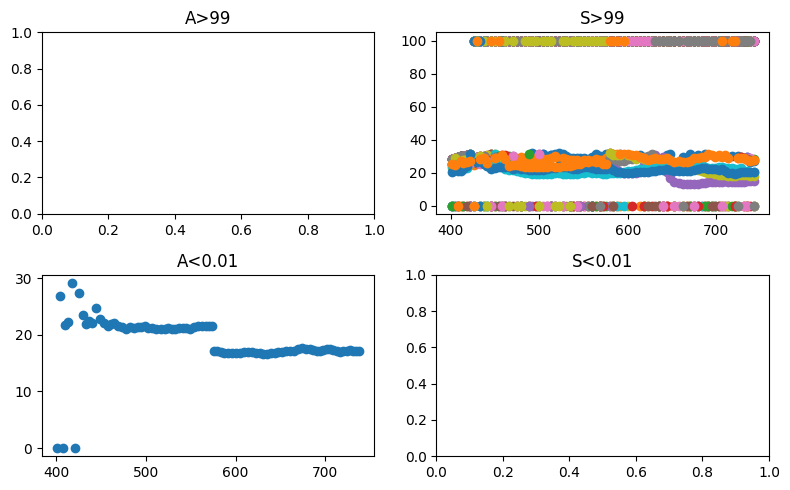

In [58]:
from custom_tools.acs_data_reader import get_acs_IOP
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

dir_path = "../data/raw/1_acs_runs/runs"
f = "run_21_ACS.407"

df_arr_A, df_arr_C = get_acs_IOP(os.path.join(dir_path, f))
wav_A = np.array(df_arr_A.columns.astype(float))
wav_C = np.array(df_arr_C.columns.astype(float))

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(8, 5))

for (i, outlier) in df_arr_A.iterrows():
    if np.any(outlier>99):
        ax[0, 0].scatter(wav_A, outlier)
    elif np.any(outlier<0.01):
        ax[1, 0].scatter(wav_A, outlier)
for (i, outlier) in df_arr_C.iterrows():
    if np.any(outlier>99):
        ax[0, 1].scatter(wav_C, outlier)
    elif np.any(outlier<0.01):
        ax[1, 1].scatter(wav_C, outlier)

ax[0, 0].set_title("A>99")
ax[1, 0].set_title("A<0.01")
ax[0, 1].set_title("S>99")
ax[1, 1].set_title("S<0.01")
plt.tight_layout()
plt.show()

# Setting the basis functions for the final version of the outlier detection and interpolation

interpolation is done if spectrum contains only local outlier and less than nmax local outliers. else whole spectrum flagged as outlier

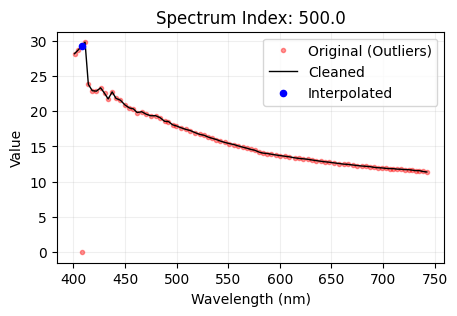

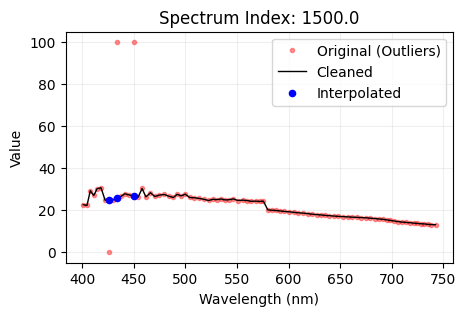

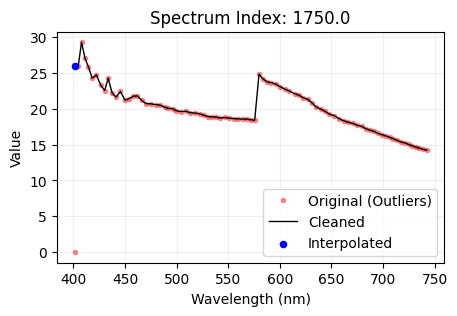

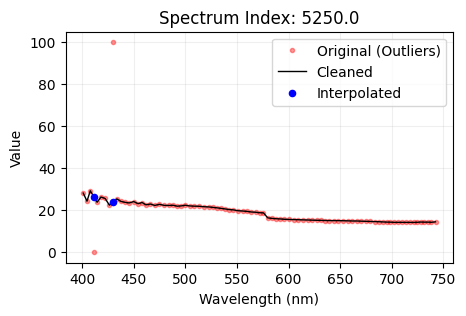

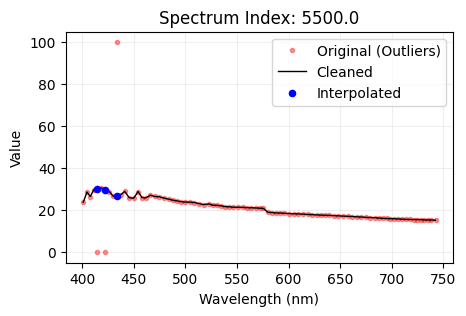

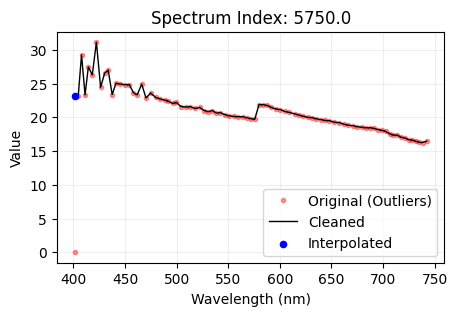

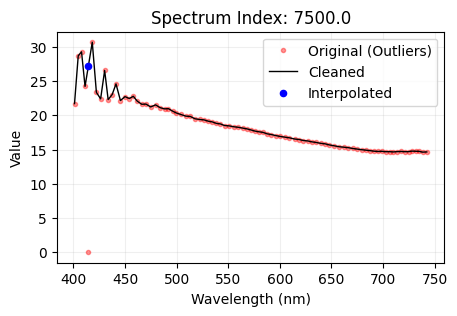

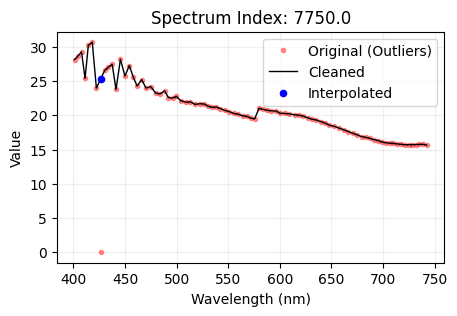

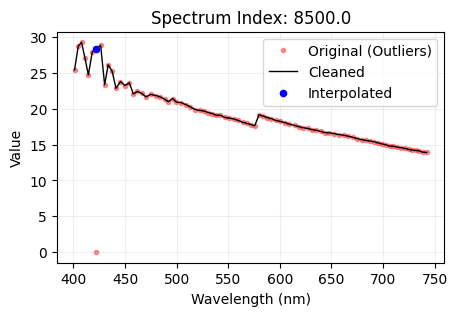

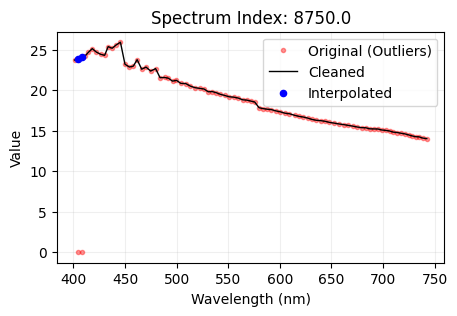

Total flagged as outliers: 1


In [67]:
import numpy as np
from scipy.ndimage import label
from custom_tools.acs_data_reader import get_acs_IOP
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

dir_path = "../data/raw/1_acs_runs/runs"
f = "run_21_ACS.044"

df_arr_A, df_arr_C = get_acs_IOP(os.path.join(dir_path, f))

wav_A = np.array(df_arr_A.columns.astype(float))

wav_C = np.array(df_arr_C.columns.astype(float))


threshold_low=0.01
threshold_high=99
max_gap=2

plot_count = 0
plot_limit = 10


cleaned_spectra = df_arr_C.copy()
flags = [] # To store indices of spectra that are beyond repair

def get_minmax_mask(sp_arr, threshold_low, threshold_high):
    return (sp_arr < threshold_low) | (sp_arr > threshold_high)

def determine_if_mask_is_recoverable(mask, max_gap: int = 2, n_max_features: int = 3):
    """
    Checks if a spectrum can be repaired based on gap size and total gap count.
    """
    # labels: an array where each outlier cluster has a unique ID
    # num_features: the total number of distinct outlier clusters found
    labels, num_features = label(mask)
    
    # 1. Check if the total number of outlier events is too high
    if num_features > n_max_features:
        return False
    
    # 2. Check if any individual outlier cluster is too wide
    if num_features > 0:
        for feat in range(1, num_features + 1):
            cluster_size = np.sum(labels == feat)
            if cluster_size > max_gap:
                return False
                
    return True

def interpolate_values_in_recoverable_spectrum(mask, wavelengths, spectrum):
    ok_indices = ~mask
    # Convert to values to ensure numpy handles the arrays cleanly
    interp_values = np.interp(
        wavelengths[mask.values], 
        wavelengths[ok_indices.values], 
        spectrum.values[ok_indices.values]
    )
    cleaned_spectrum = spectrum.copy()
    cleaned_spectrum[mask] = interp_values
    return cleaned_spectrum, interp_values
    
def plot_spectrum_before_and_after_recovery(wavelengths, original_sp, cleaned_sp, idx, interp_vals, mask):
    plt.figure(figsize=(5, 3))
    plt.plot(wavelengths, original_sp, 'r.', alpha=0.4, label='Original (Outliers)')
    plt.plot(wavelengths, cleaned_sp, 'k-', linewidth=1, label='Cleaned')
    plt.scatter(wavelengths[mask.values], interp_vals, color='blue', s=20, zorder=5, label='Interpolated')
    
    plt.title(f"Spectrum Index: {idx}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()






# Main Loop
for (i, spectrum) in df_arr_C.iterrows():
    mask = get_minmax_mask(spectrum, threshold_low, threshold_high)
    
    if not np.any(mask):
        continue
            
    if determine_if_mask_is_recoverable(mask, n_max_features=3):
        clean_sp, interp_v = interpolate_values_in_recoverable_spectrum(mask, wav_C, spectrum)
        cleaned_spectra.loc[i, :] = clean_sp
        
        if plot_count < plot_limit:
            plot_spectrum_before_and_after_recovery(wav_C, spectrum, clean_sp, i, interp_v, mask)
            plot_count += 1
    else:
        flags.append(i)

print(f"Total flagged as outliers: {len(flags)}")

# Analysis to determine n_max 

Calculate the number of single outliers found in every spectrum of the dataset

In [56]:
from custom_tools.acs_data_reader import get_acs_IOP
import numpy as np
import pandas as pd
from scipy.ndimage import label
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

dir_path = "../data/raw/1_acs_runs/runs"

file_list = [ff for ff in os.listdir(dir_path) if ff.startswith('run_21_ACS.')]

metadata = pd.read_csv("../data/raw/1_acs_runs/metadata_acs.csv")

def get_minmax_mask(sp_arr, threshold_low, threshold_high):
    return (sp_arr < threshold_low) | (sp_arr > threshold_high)

def characterize_mask(mask):
    """
    Checks if a spectrum can be repaired based on gap size and total gap count.
    """
   
    only_local_outliers = True
    
    labels, num_features = label(mask)
       
    if num_features > 0:
        for feat in range(1, num_features + 1):
            cluster_size = np.sum(labels == feat)
            if cluster_size > 2:
                only_local_outliers = False
                
    return only_local_outliers, num_features

# 1. Initialize an empty list before your loops
outlier_logs_A = []
outlier_logs_S = []

for f in file_list:
    samplename = metadata.loc[metadata["run_nr"]==int(f[-3:]), "sample_name"].values[0]
    
    if "diw" not in samplename:
    
        try:
            df_arr_A, df_arr_S = get_acs_IOP(os.path.join(dir_path, f))
            wav_A = np.array(df_arr_A.columns[1:].astype(float))
            wav_C = np.array(df_arr_C.columns[1:].astype(float))
            
            for (i, spectrum) in df_arr_A.iterrows():
                mask = get_minmax_mask(spectrum, threshold_low, threshold_high)
    
                if not np.any(mask):
                    continue
                    
                only_local_outliers, num_features = characterize_mask(mask)
                
                    # 2. Append the info if outliers were found
                if num_features > 0:
                    outlier_logs_A.append({
                        "file": f,
                        "sample": samplename,
                        "row_index": i,
                        "num_outlier_clusters": num_features,
                        "only_local_outliers": only_local_outliers,
                    })
                    
            for (i, spectrum) in df_arr_S.iterrows():
                mask = get_minmax_mask(spectrum, threshold_low, threshold_high)
    
                if not np.any(mask):
                    continue
                    
                only_local_outliers, num_features = characterize_mask(mask)
                
                    # 2. Append the info if outliers were found
                if num_features > 0:
                    outlier_logs_S.append({
                        "file": f,
                        "sample": samplename,
                        "row_index": i,
                        "num_outlier_clusters": num_features,
                        "only_local_outliers": only_local_outliers,
                    })
        
        
        except: 
            print(f"Failed for: {f}")
            
# 3. Convert the list to a DataFrame after all loops are finished
df_outlier_report_A = pd.DataFrame(outlier_logs_A)
df_outlier_report_S = pd.DataFrame(outlier_logs_S)

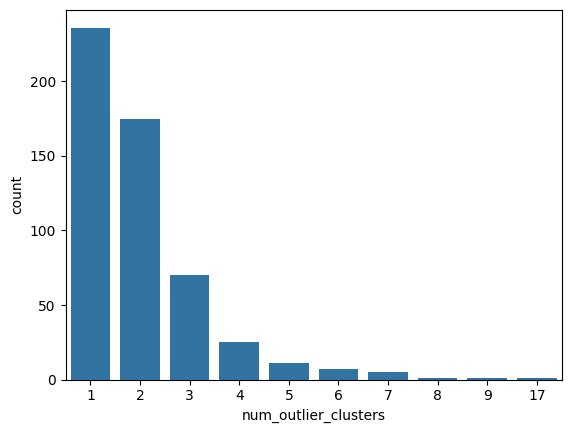

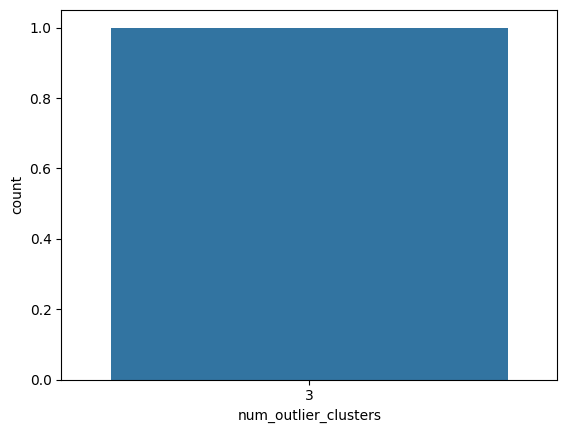

In [63]:
import seaborn as sns

sns.countplot(data=df_outlier_report_S[df_outlier_report_S["only_local_outliers"]], x="num_outlier_clusters")
plt.show()

sns.countplot(data=df_outlier_report_A[df_outlier_report_A["only_local_outliers"]], x="num_outlier_clusters")
plt.show()

**Conclusion** First of all, it seems that the absorbance spectra have very little single outliers, I verified this visually in the fisrt dozens of runs. Second, based on the count of single outliers in the scattering spectra, it seems that most spectra have either 1, 2, or 3 single outliers. Therefore, **N_max = 3 seems a good decision.**. This will enable me to "save" almost 500 spectra!

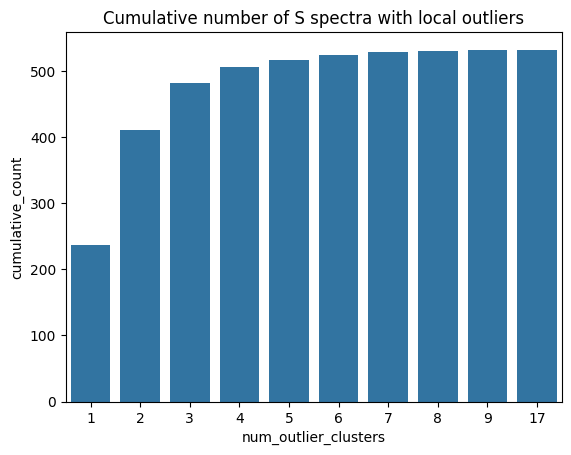

In [66]:
cum_data = df_outlier_report_S[df_outlier_report_S["only_local_outliers"]]["num_outlier_clusters"].value_counts().sort_index().cumsum().reset_index()
cum_data.columns = ["num_outlier_clusters", "cumulative_count"]

# 3. Plot the cumulative counts
sns.barplot(data=cum_data, x="num_outlier_clusters", y="cumulative_count")
plt.title("Cumulative number of S spectra with local outliers")
plt.show()